In [1]:
import Pkg; Pkg.activate(@__DIR__); Pkg.instantiate()

  Activating new project at `~/Library/Mobile Documents/com~apple~CloudDocs/Desktop/UCLA/research/vectr/minimum-time-quadrotor-trajectory`
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Desktop/UCLA/research/vectr/minimum-time-quadrotor-trajectory/Project.toml`
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Desktop/UCLA/research/vectr/minimum-time-quadrotor-trajectory/Manifest.toml`


In [2]:
using LinearAlgebra
using Plots
using ForwardDiff
using Ipopt
using MathOptInterface
const MOI = MathOptInterface;
using LaTeXStrings

[ Info: Precompiling IJuliaExt [64482eec-cc57-5312-bea1-9f24eb636db7] (cache misses: wrong dep version loaded (2))
[ Info: Precompiling IJuliaExt [2f4121a4-3b3a-5ce6-9c5e-1f2673ce168a] (cache misses: wrong dep version loaded (6))


In [3]:
h = 0.1

0.1

In [4]:
Nx = 5     # number of state
Nu = 2     # number of controls
tau_final = 1.0 # final time
Nt = Int(tau_final/h)+1   # number of time steps
thist = Array(range(0,h*(Nt-1), step=h));
n_nlp = 1 + (Nx+Nu)*Nt # number of decision variables, add 1 for the final time Tfinal
m_nlp = Nx*(Nt+1)
# m_nlp = Nx*(Nt+1) + 1 # account for two constraints on angle

60

In [5]:
function drone_dynamics(x, u, T)
    # x = [x, xdot, z, zdot, theta]
    # u = [uT, uR]
    xdot = x[2]
    zdot = x[4]
    return T * [xdot, u[1]*sin(x[5]), zdot, u[1]*cos(x[5]) - 1, u[2]]
end

drone_dynamics (generic function with 1 method)

In [6]:
function dircol_dynamics(x1,u1,x2,u2, T)
    #Hermite-Simpson integration with first-order hold on u
    f1 = drone_dynamics(x1, u1, T)
    f2 = drone_dynamics(x2, u2, T)
    xm = 0.5*(x1 + x2) + (h/8.0)*(f1 - f2)
    um = 0.5*(u1 + u2)
    ẋm = (-3/(2.0*h))*(x1 - x2) - 0.25*(f1 + f2)
    fm = drone_dynamics(xm, um, T)
    return fm - ẋm
end

dircol_dynamics (generic function with 1 method)

In [7]:
# Cost weights
Q = 0.0 * Diagonal(ones(Nx));
R = 1e-4;

In [8]:
# original
function stage_cost(x,u)
    return 0.5*((x-xgoal)'*Q*(x-xgoal)) + 0.5*u'*R*u
end

# function stage_cost(x,u)
#     return 0.5*u'*R*u
# end

# function stage_cost(x,u)
#     return 0.5*((x-xgoal)'*Q*(x-xgoal)) 
# end

stage_cost (generic function with 1 method)

In [9]:
function cost(ztraj)
    # account for final time 
    z = reshape(ztraj[2:end],Nx+Nu,Nt) # skip the first variable which is Tfinal
    J = 0.0
    for k = 1:Nt
        J += stage_cost(z[1:Nx,k],z[(Nx+1):(Nx+Nu),k]) 
    end
    return J + ztraj[1] # add final time to the cost
end

cost (generic function with 1 method)

In [10]:
function dynamics_constraint!(c,ztraj)
    # account for the final time variable
    Tfinal = ztraj[1]
    d = reshape(c,Nx,Nt-1)
    z = reshape(ztraj[2:end],Nx+Nu,Nt) # skip the first variable which is Tfinal
    for k = 1:(Nt-1)
        x1 = z[1:Nx,k]
        u1 = z[(Nx+1):(Nx+Nu),k]
        x2 = z[1:Nx,k+1]
        u2 = z[(Nx+1):(Nx+Nu),k+1]
        d[:,k] = dircol_dynamics(x1,u1,x2,u2, Tfinal)
    end
    return nothing
end

dynamics_constraint! (generic function with 1 method)

In [11]:
function con_original!(c,ztraj)
    z = reshape(ztraj[2:end], Nx+Nu, Nt) # skip first variable Tfinal
    c[1:Nx] .= z[1:Nx,1] - x0
    idx_dyn_start = Nx + 1
    idx_dyn_end = Nx + Nx*(Nt-1)
    @views dynamics_constraint!(c[idx_dyn_start:idx_dyn_end], ztraj)
    idx_term_start = idx_dyn_end + 1
    c[idx_term_start:(idx_term_start+Nx-1)] .= z[1:Nx,end] - xgoal
    return nothing
end

function con_periodic!(c,ztraj)
    z = reshape(ztraj[2:end], Nx+Nu, Nt) # skip first variable Tfinal
    c[1:Nx] .= z[1:Nx,1] - x0
    idx_dyn_start = Nx + 1
    idx_dyn_end = Nx + Nx*(Nt-1)
    @views dynamics_constraint!(c[idx_dyn_start:idx_dyn_end], ztraj)
    idx_term_start = idx_dyn_end + 1
    c[idx_term_start:(idx_term_start+Nx-2)] .= z[1:Nx-1,end] - xgoal[1:Nx-1]
    theta = z[Nx,end]
    c[idx_term_start+Nx-1] = sin(theta) - sin(xgoal[Nx])
    c[idx_term_start+Nx] = cos(theta) - cos(xgoal[Nx])
    return nothing
end

# pick one: con_original! (requires m_nlp = Nx*(Nt+1))
# or con_periodic! (requires m_nlp = Nx*(Nt+1) + 1)
function con!(c,ztraj)
    con_original!(c,ztraj)
    # con_periodic!(c,ztraj)
end

con! (generic function with 1 method)

In [12]:
struct ProblemMOI <: MOI.AbstractNLPEvaluator
    n_nlp::Int
    m_nlp::Int
    idx_ineq
    obj_grad::Bool
    con_jac::Bool
    sparsity_jac
    sparsity_hess
    primal_bounds
    constraint_bounds
    hessian_lagrangian::Bool
end

function ProblemMOI(n_nlp,m_nlp;
        idx_ineq=(1:0),
        obj_grad=true,
        con_jac=true,
        sparsity_jac=sparsity_jacobian(n_nlp,m_nlp),
        sparsity_hess=sparsity_hessian(n_nlp,m_nlp),
        primal_bounds=primal_bounds(n_nlp),
        constraint_bounds=constraint_bounds(m_nlp,idx_ineq=idx_ineq),
        hessian_lagrangian=false)

    ProblemMOI(n_nlp,m_nlp,
        idx_ineq,
        obj_grad,
        con_jac,
        sparsity_jac,
        sparsity_hess,
        primal_bounds,
        constraint_bounds,
        hessian_lagrangian)
end

function primal_bounds(n; T_min=1.0e-6, g=9.81, u1_min=1/g, u1_max=20/g, u2_min=-1.0, u2_max=1.0)
    x_l = -Inf*ones(n)
    x_u = Inf*ones(n)
    x_l[1] = T_min
    for k = 1:Nt
        idx_u1 = 1 + (k-1)*(Nx+Nu) + (Nx+1)
        idx_u2 = idx_u1 + 1
        x_l[idx_u1] = u1_min
        x_u[idx_u1] = u1_max
        x_l[idx_u2] = u2_min
        x_u[idx_u2] = u2_max
    end
    return x_l, x_u
end

function constraint_bounds(m; idx_ineq=(1:0))
    c_l = zeros(m)
    c_l[idx_ineq] .= -Inf

    c_u = zeros(m)
    return c_l, c_u
end

function row_col!(row,col,r,c)
    for cc in c
        for rr in r
            push!(row,rr)
            push!(col,cc)
        end
    end
    return row, col
end

function sparsity_jacobian(n,m)

    row = Int[]
    col = Int[]

    r = 1:m
    c = 1:n

    row_col!(row,col,r,c)

    return [(row[i], col[i]) for i in 1:length(row)]
end

function sparsity_hessian(n,m)

    row = Int[]
    col = Int[]

    r = 1:m
    c = 1:n

    row_col!(row,col,r,c)

    return [(row[i], col[i]) for i in 1:length(row)]
end

function MOI.eval_objective(prob::MOI.AbstractNLPEvaluator, x)
    cost(x)
end

function MOI.eval_objective_gradient(prob::MOI.AbstractNLPEvaluator, grad_f, x)
    ForwardDiff.gradient!(grad_f,cost,x)
    return nothing
end

function MOI.eval_constraint(prob::MOI.AbstractNLPEvaluator,g,x)
    con!(g,x)
    return nothing
end

function MOI.eval_constraint_jacobian(prob::MOI.AbstractNLPEvaluator, jac, x)
    ForwardDiff.jacobian!(reshape(jac,prob.m_nlp,prob.n_nlp), con!, zeros(prob.m_nlp), x)
    return nothing
end

function MOI.features_available(prob::MOI.AbstractNLPEvaluator)
    return [:Grad, :Jac]
end

MOI.initialize(prob::MOI.AbstractNLPEvaluator, features) = nothing
MOI.jacobian_structure(prob::MOI.AbstractNLPEvaluator) = prob.sparsity_jac

function solve(x0,prob::MOI.AbstractNLPEvaluator;
        tol=1.0e-4,c_tol=1.0e-4,max_iter=1000)
    x_l, x_u = prob.primal_bounds
    c_l, c_u = prob.constraint_bounds

    nlp_bounds = MOI.NLPBoundsPair.(c_l,c_u)
    block_data = MOI.NLPBlockData(nlp_bounds,prob,true)

    solver = Ipopt.Optimizer()
    solver.options["max_iter"] = max_iter
    solver.options["tol"] = tol
    solver.options["constr_viol_tol"] = c_tol

    x = MOI.add_variables(solver,prob.n_nlp)

    for i = 1:prob.n_nlp
        MOI.add_constraint(solver, x[i], MOI.LessThan(x_u[i]))
        MOI.add_constraint(solver, x[i], MOI.GreaterThan(x_l[i]))
        MOI.set(solver, MOI.VariablePrimalStart(), x[i], x0[i])
    end

    # Solve the problem
    MOI.set(solver, MOI.NLPBlock(), block_data)
    MOI.set(solver, MOI.ObjectiveSense(), MOI.MIN_SENSE)
    MOI.optimize!(solver)

    # Get the solution
    res = MOI.get(solver, MOI.VariablePrimal(), x)

    return res
end

solve (generic function with 1 method)

In [13]:
g = 9.81
w = 10;           

In [14]:
#Initial and goal states
x0 = [0; 0; 0; 0; 0]
xgoal = [0; 0; 5 * w^2 / g; 0; 2*pi]

5-element Vector{Float64}:
  0.0
  0.0
 50.9683995922528
  0.0
  6.283185307179586

In [15]:
#Guess
xguess = kron(ones(Nt)', x0)
# xguess[1,:] .= xtraj[1,:] + 0.1*randn(Nt)
uguess = zeros(Nu, Nt)
# z0 = reshape([xguess; uguess],(Nx+Nu)*Nt,1);
Tguess = 10
z0 = [Tguess; reshape([xguess; uguess],(Nx+Nu)*Nt,1)];

In [16]:
prob = ProblemMOI(n_nlp,m_nlp; primal_bounds=primal_bounds(n_nlp, T_min=1.0e-3, g=9.81))

ProblemMOI(78, 60, 1:0, true, true, [(1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1)  …  (51, 78), (52, 78), (53, 78), (54, 78), (55, 78), (56, 78), (57, 78), (58, 78), (59, 78), (60, 78)], [(1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1)  …  (51, 78), (52, 78), (53, 78), (54, 78), (55, 78), (56, 78), (57, 78), (58, 78), (59, 78), (60, 78)], ([0.001, -Inf, -Inf, -Inf, -Inf, -Inf, 0.1019367991845056, -1.0, -Inf, -Inf  …  -Inf, 0.1019367991845056, -1.0, -Inf, -Inf, -Inf, -Inf, -Inf, 0.1019367991845056, -1.0], [Inf, Inf, Inf, Inf, Inf, Inf, 2.038735983690112, 1.0, Inf, Inf  …  Inf, 2.038735983690112, 1.0, Inf, Inf, Inf, Inf, Inf, 2.038735983690112, 1.0]), ([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]), false)

In [17]:
z_sol = solve(z0,prob) # solve


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:     4680
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:       78
                     variables with only lower bounds:        1
                variables with lower and upper bounds:       22
                     variables with only upper bounds:        0
Total number of equality constraints.................:       60
Total number of inequality c

78-element Vector{Float64}:
 13.149336145477111
  0.0
  0.0
  5.876084482698371e-30
  0.0
 -2.0526125003776134e-31
  2.0387360040603104
 -0.024090478051035896
 -0.014465537954138631
 -0.029850543466373808
  0.8979244126540009
  1.365664511899377
 -0.01756716865616881
  ⋮
 50.17975418535638
  1.2162074544314783
  4.968251679520553
  0.10193679193456498
  1.0000000099783557
 -6.365677424224549e-29
  2.4858737837620335e-27
 50.9683995922528
  0.0
  6.283185307179586
  0.10193678922446449
  1.0000000099638313

In [18]:
# ztraj = reshape(z_sol,Nx+Nu,Nt)
# account for the final time variable
ztraj = reshape(z_sol[2:end],Nx+Nu,Nt) # skip the first variable which is Tfinal
xtraj = ztraj[1:Nx,:]
utraj = ztraj[(Nx+1):(Nx+Nu),:];

In [19]:
Tfinal = z_sol[1]
t_actual = thist * Tfinal / w
println("Optimal final time: ", Tfinal / w)

Optimal final time: 1.314933614547711


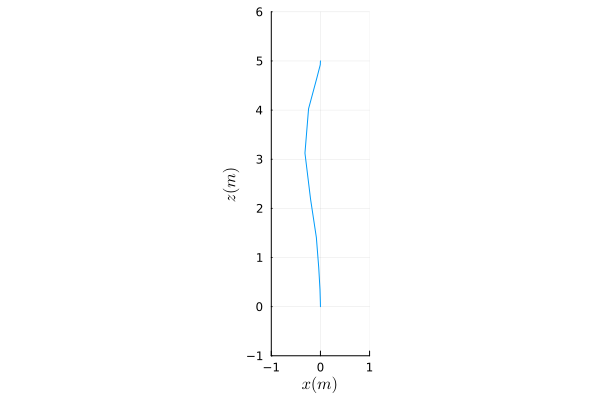

In [20]:
plot(xtraj[1,:]*g/w^2, xtraj[3,:]*g/w^2, aspect_ratio = :equal, legend = false)
xlims!(-1, 1)
xticks!(-1:1:1)
ylims!(-1, 6)
xlabel!(L"x(m)")
ylabel!(L"z(m)")
# savefig("traj_vert_h01_2pi.png")

In [21]:
p1 = plot(t_actual,xtraj[1,:]*g/w^2, label=L"x(m)", xlabel=L"t(s)", color=:blue, legend=:topleft)
plot!(p1, t_actual,xtraj[2,:]*g/w, label=L"\dot{x}(\frac{m}{s})", color=:blue, linestyle=:dash)
plot!(p1, t_actual,xtraj[3,:]*g/w^2, label=L"z(m)", color=:green)
plot!(p1, t_actual,xtraj[4,:]*g/w, label=L"\dot{z}(\frac{m}{s})", color=:green, linestyle=:dash)
plot!(p1, t_actual,xtraj[5,:], label=L"\theta(rad)", color=:black, linestyle=:dot)
ylims!(p1, -1.8, 8.2)

p2 = plot(t_actual,utraj[2,:] * w, xlabel=L"t(s)", label=L"\omega(\frac{rad}{s})", legend=:topleft, color=:blue)
plot!(p2, t_actual,utraj[1,:] * g, label=L"\frac{F_T}{m}(\frac{m}{s^2})", color=:green)
ylims!(p2, -16, 23)

xlims!(p1, 0, t_actual[end])
xlims!(p2, 0, t_actual[end])
plot(p2, p1, layout = (2, 1), size=(700, 700))
savefig("vert_states_h01_2pi.png")

"/Users/wuqiyuan/Library/Mobile Documents/com~apple~CloudDocs/Desktop/UCLA/research/vectr/minimum-time-quadrotor-trajectory/vert_states_h01_2pi.png"